In [2]:
!pip install pandas numpy nltk scikit-learn matplotlib wordcloud joblib sentence-transformers tensorflow seaborn

  Using cached click-8.5.0-py3-none-any.whl.metadata (2.6 kB)
   ---------------------------------------- 0.0/739.8 kB ? eta -:--:--
   ---------------------------------------- 739.8/739.8 kB 15.1 MB/s  0:00:00
   ---------------------------------------- 0.0/795.8 kB ? eta -:--:--
   ---------------------------------------- 795.8/795.8 kB 16.2 MB/s  0:00:00
Using cached click-8.5.0-py3-none-any.whl (125 kB)
   ---------------------------------------- 0.0/4.0 MB ? eta -:--:--
   -------------------------------------- - 3.9/4.0 MB 18.5 MB/s eta 0:00:01
   ---------------------------------------- 4.0/4.0 MB 16.9 MB/s  0:00:00
   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   -------------------------- ------------- 8.1/12.1 MB 37.9 MB/s eta 0:00:01
   ---------------------------------------- 12.1/12.1 MB 29.8 MB/s  0:00:00
   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   ---------------------------------------- 2.8/2.8 MB 24.3 MB/s  0:00:00
  

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
spyder 6.0.7 requires ipython!=8.17.1,<9.0.0,>=8.13.0; python_version > "3.8", but you have ipython 9.7.0 which is incompatible.

[notice] A new release of pip is available: 26.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Importing Libraries

In [152]:
# Data Handling
import pandas as pd
import numpy as np

# NLP
import nltk
import re

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# Model Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split,RandomizedSearchCV

# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

# Sentence Embeddings
from sentence_transformers import SentenceTransformer

# Artificial Neural Network
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

import optuna

import os

# Model Saving
import joblib

## Dataset Collection

In [7]:
train_df = pd.read_csv("dataset/train.csv")
display(train_df)

test_df = pd.read_csv("dataset/test.csv")
display(test_df)

,text,category
0,I am still waiting on my card?,card_arrival
1,What can I do if my card still hasn't arrived ...,card_arrival
2,I have been waiting over a week. Is the card s...,card_arrival
3,Can I track my card while it is in the process...,card_arrival
4,"How do I know if I will get my card, or if it ...",card_arrival
...,...,...
9998,You provide support in what countries?,country_support
9999,What countries are you supporting?,country_support
10000,What countries are getting support?,country_support
10001,Are cards available in the EU?,country_support


,text,category
0,How do I locate my card?,card_arrival
1,"I still have not received my new card, I order...",card_arrival
2,I ordered a card but it has not arrived. Help ...,card_arrival
3,Is there a way to know when my card will arrive?,card_arrival
4,My card has not arrived yet.,card_arrival
...,...,...
3075,"If i'm not in the UK, can I still get a card?",country_support
3076,How many countries do you support?,country_support
3077,What countries do you do business in?,country_support
3078,What are the countries you operate in.,country_support


## Data Understanding

In [8]:
display(train_df.head())
display(test_df.head())

,text,category
0,I am still waiting on my card?,card_arrival
1,What can I do if my card still hasn't arrived ...,card_arrival
2,I have been waiting over a week. Is the card s...,card_arrival
3,Can I track my card while it is in the process...,card_arrival
4,"How do I know if I will get my card, or if it ...",card_arrival


,text,category
0,How do I locate my card?,card_arrival
1,"I still have not received my new card, I order...",card_arrival
2,I ordered a card but it has not arrived. Help ...,card_arrival
3,Is there a way to know when my card will arrive?,card_arrival
4,My card has not arrived yet.,card_arrival


#### Shape of the Datasets

In [9]:
print("Training Dataset Shape: ", train_df.shape)
print("Testing Dataset Shape: ", test_df.shape)

Training Dataset Shape:  (10003, 2)
Testing Dataset Shape:  (3080, 2)


#### Dataset Info

In [10]:
print(train_df.info)
print(test_df.info)

<bound method DataFrame.info of                                                     text         category
0                         I am still waiting on my card?     card_arrival
1      What can I do if my card still hasn't arrived ...     card_arrival
2      I have been waiting over a week. Is the card s...     card_arrival
3      Can I track my card while it is in the process...     card_arrival
4      How do I know if I will get my card, or if it ...     card_arrival
...                                                  ...              ...
9998              You provide support in what countries?  country_support
9999                  What countries are you supporting?  country_support
10000                What countries are getting support?  country_support
10001                     Are cards available in the EU?  country_support
10002                   Which countries are represented?  country_support

[10003 rows x 2 columns]>
<bound method DataFrame.info of                      

* The dataset contains two columns:

- `text` – contains the customer's banking query.
- `category` – contains the corresponding banking issue category.

The training and testing datasets are already provided separately by the
BANKING77 dataset.

#### Missing Values

In [12]:
print("Training Dataset:\n")
print(train_df.isna().sum())

print("\nTesting Dataset:")
print(test_df.isna().sum())

Training Dataset:

text        0
category    0
dtype: int64

Testing Dataset:
text        0
category    0
dtype: int64


* There are no missing values in both training and testing Datasets 

In [13]:
display(train_df["category"].value_counts())
display(test_df["category"].value_counts())

category
card_payment_fee_charged                            187
direct_debit_payment_not_recognised                 182
balance_not_updated_after_cheque_or_cash_deposit    181
wrong_amount_of_cash_received                       180
cash_withdrawal_charge                              177
                                                   ... 
lost_or_stolen_card                                  82
card_swallowed                                       61
card_acceptance                                      59
virtual_card_not_working                             41
contactless_not_working                              35
Name: count, Length: 77, dtype: int64

category
card_arrival                        40
card_linking                        40
exchange_rate                       40
card_payment_wrong_exchange_rate    40
extra_charge_on_statement           40
                                    ..
cash_withdrawal_charge              40
card_about_to_expire                40
apple_pay_or_google_pay             40
verify_my_identity                  40
country_support                     40
Name: count, Length: 77, dtype: int64

#### Duplicate records

In [14]:
print("Duplicate Records in Training Dataset:",
      train_df.duplicated().sum())

print("Duplicate Records in Testing Dataset:",
      test_df.duplicated().sum())

Duplicate Records in Training Dataset: 0
Duplicate Records in Testing Dataset: 0


In [15]:
print("Duplicate Texts in Training Dataset:",
      train_df["text"].duplicated().sum())

print("Duplicate Texts in Testing Dataset:",
      test_df["text"].duplicated().sum())

Duplicate Texts in Training Dataset: 0
Duplicate Texts in Testing Dataset: 0


Duplicate records were checked in both the training and testing datasets.
Duplicate records can give repeated examples more influence during model
training.

The dataset was checked for duplicate rows as well as duplicate text
queries. No problematic duplicate records were identified.

#### Incorrect Data

In [16]:
print("Training Dataset Columns:")
print(train_df.columns.tolist())

print("\nData Types:")
print(train_df.dtypes)

print("\nNumber of Categories:",
      train_df["category"].nunique())

print("\nEmpty Text Values:",
      train_df["text"].astype(str).str.strip().eq("").sum())

print("Empty Category Values:",
      train_df["category"].astype(str).str.strip().eq("").sum())

Training Dataset Columns:
['text', 'category']

Data Types:
text        str
category    str
dtype: object

Number of Categories: 77

Empty Text Values: 0
Empty Category Values: 0


The dataset was checked for incorrect or unexpected values by examining
the column names, data types, empty text values, empty category values,
and the number of target categories.

The dataset contains the expected `text` and `category` columns. The text
and category fields contain valid values, and all 77 expected categories
are present.

No obvious incorrect or invalid records were identified during the
initial data quality check.

#### Class Imbalance

In [17]:
train_class_counts = train_df["category"].value_counts()
test_class_counts = test_df["category"].value_counts()

print("Training Dataset Class Distribution:")
print(train_class_counts)

print("\nTesting Dataset Class Distribution:")
print(test_class_counts)

Training Dataset Class Distribution:
category
card_payment_fee_charged                            187
direct_debit_payment_not_recognised                 182
balance_not_updated_after_cheque_or_cash_deposit    181
wrong_amount_of_cash_received                       180
cash_withdrawal_charge                              177
                                                   ... 
lost_or_stolen_card                                  82
card_swallowed                                       61
card_acceptance                                      59
virtual_card_not_working                             41
contactless_not_working                              35
Name: count, Length: 77, dtype: int64

Testing Dataset Class Distribution:
category
card_arrival                        40
card_linking                        40
exchange_rate                       40
card_payment_wrong_exchange_rate    40
extra_charge_on_statement           40
                                    ..
cash_withdrawal_char

In [18]:
print("Maximum Training Class Count:",
      train_class_counts.max())

print("Minimum Training Class Count:",
      train_class_counts.min())

imbalance_ratio = (
    train_class_counts.max() /
    train_class_counts.min()
)

print("Imbalance Ratio:",
      round(imbalance_ratio, 2))

Maximum Training Class Count: 187
Minimum Training Class Count: 35
Imbalance Ratio: 5.34


The distribution of records across the 77 categories was examined to
identify any class imbalance.

The training dataset contains between 35 and 187 records per category,
resulting in an imbalance ratio of approximately 5.34.

The testing dataset is balanced, with 40 records available for each
category.

Therefore, the training dataset has some class imbalance, which will be
considered when evaluating the models using precision, recall and
F1-score in addition to accuracy.

#### Number of records

In [19]:
print("Number of Training Records:", len(train_df))
print("Number of Testing Records:", len(test_df))
print("Total Number of Records:", len(train_df) + len(test_df))

Number of Training Records: 10003
Number of Testing Records: 3080
Total Number of Records: 13083


The BANKING77 dataset contains a total of 13,083 records.

The dataset is already divided into:
- 10,003 training records
- 3,080 testing records

The original train-test split provided with the dataset will be retained
for model development and final evaluation.

## Text Feature Engineering

In [20]:
# Calculate the number of words in each query
train_df["word_count"] = train_df["text"].str.split().str.len()

train_df[["text", "word_count"]].head()

,text,word_count
0,I am still waiting on my card?,7
1,What can I do if my card still hasn't arrived ...,13
2,I have been waiting over a week. Is the card s...,12
3,Can I track my card while it is in the process...,13
4,"How do I know if I will get my card, or if it ...",15


In [21]:
# Calculate the number of characters in each query
train_df["char_count"] = train_df["text"].str.len()


train_df[["text", "char_count"]].head()

,text,char_count
0,I am still waiting on my card?,30
1,What can I do if my card still hasn't arrived ...,60
2,I have been waiting over a week. Is the card s...,58
3,Can I track my card while it is in the process...,59
4,"How do I know if I will get my card, or if it ...",54


In [22]:
# Calculate average word length
train_df["avg_word_length"] = (
    train_df["char_count"] / train_df["word_count"]
)


train_df[["text", "word_count", "char_count", "avg_word_length"]].head()

,text,word_count,char_count,avg_word_length
0,I am still waiting on my card?,7,30,4.285714
1,What can I do if my card still hasn't arrived ...,13,60,4.615385
2,I have been waiting over a week. Is the card s...,12,58,4.833333
3,Can I track my card while it is in the process...,13,59,4.538462
4,"How do I know if I will get my card, or if it ...",15,54,3.600000


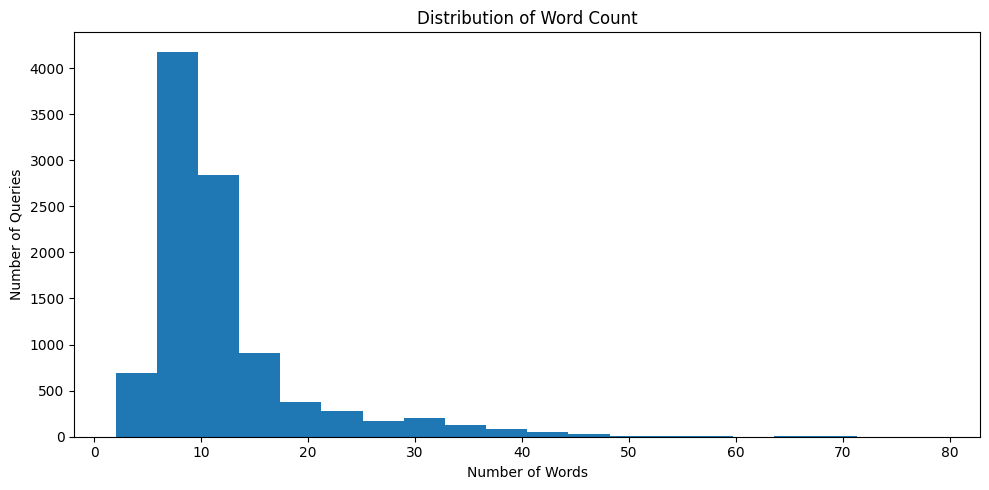

In [23]:
# Word Count Visualization

plt.figure(figsize=(10, 5))

plt.hist(train_df["word_count"], bins=20)

plt.title("Distribution of Word Count")
plt.xlabel("Number of Words")
plt.ylabel("Number of Queries")

plt.tight_layout()
plt.show()

In [24]:
# Word frequency
from collections import Counter

all_words = " ".join(
    train_df["text"].astype(str)
).lower().split()

word_frequency = Counter(all_words)

word_frequency.most_common(20)

[('i', 8309),
 ('my', 5684),
 ('to', 4011),
 ('a', 3565),
 ('the', 3497),
 ('is', 2339),
 ('can', 1839),
 ('do', 1730),
 ('card', 1636),
 ('it', 1557),
 ('for', 1534),
 ('how', 1511),
 ('what', 1367),
 ('why', 1233),
 ('and', 1213),
 ('you', 1178),
 ('was', 1089),
 ('have', 975),
 ('not', 953),
 ('in', 944)]

Basic text features such as word count, character count and average word
length were created to understand the characteristics of the customer
queries.

Word frequency was also examined to identify commonly occurring terms in
the dataset.

These features are mainly used for exploratory analysis. The complete
text will be used for further preprocessing and semantic sentence
embedding during the vectorization stage.

## Word Cloud

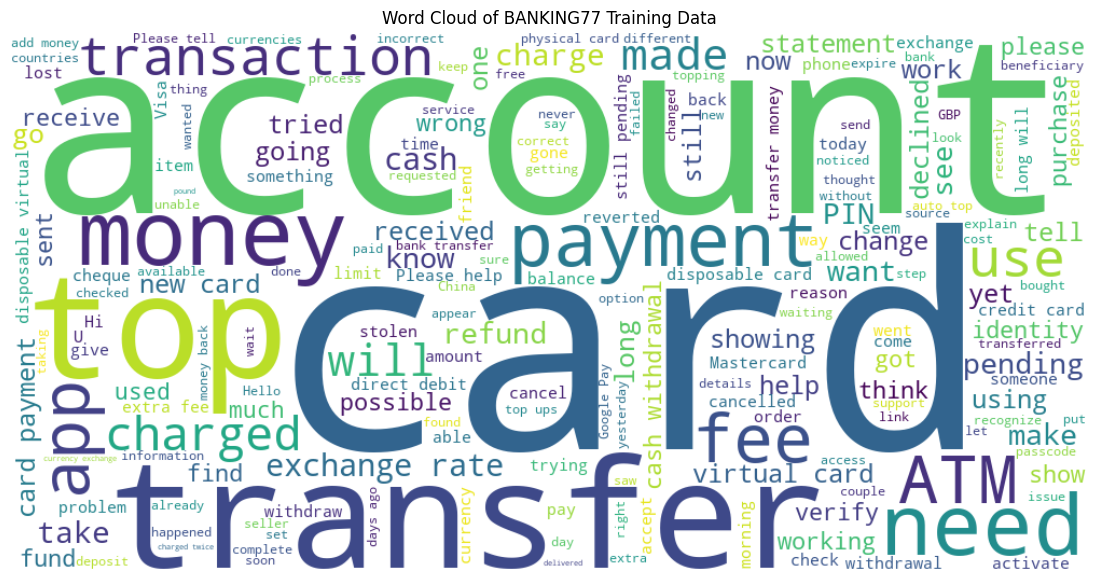

In [25]:
text = " ".join(train_df["text"].astype(str))

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(text)

plt.figure(figsize=(15, 7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of BANKING77 Training Data")

plt.show()

* This visualization helps us understand the common terms used by
customers in the BANKING77 dataset.

## Text Preprocessing

Text preprocessing is performed to clean the customer queries before
converting them into numerical representations.

The preprocessing steps used in this project are:

1. Convert text to lowercase.
2. Remove unnecessary characters.
3. Remove extra whitespace.

The preprocessing is kept relatively simple because sentence embeddings
use the semantic meaning of the complete sentence. Therefore, aggressive
removal of words such as stop words is avoided.

In [26]:
def preprocess_text(text):
    
    # Convert text to lowercase
    text = text.lower()
    
    # Remove unnecessary characters
    text = re.sub(r"[^a-zA-Z0-9\s]", "", text)
    
    # Remove extra whitespace
    text = re.sub(r"\s+", " ", text).strip()
    
    return text

In [27]:
train_df["processed_text"] = train_df["text"].apply(preprocess_text)

test_df["processed_text"] = test_df["text"].apply(preprocess_text)

In [28]:
train_df[["text", "processed_text"]].head(10)

,text,processed_text
0,I am still waiting on my card?,i am still waiting on my card
1,What can I do if my card still hasn't arrived ...,what can i do if my card still hasnt arrived a...
2,I have been waiting over a week. Is the card s...,i have been waiting over a week is the card st...
3,Can I track my card while it is in the process...,can i track my card while it is in the process...
4,"How do I know if I will get my card, or if it ...",how do i know if i will get my card or if it i...
5,When did you send me my new card?,when did you send me my new card
6,Do you have info about the card on delivery?,do you have info about the card on delivery
7,What do I do if I still have not received my n...,what do i do if i still have not received my n...
8,Does the package with my card have tracking?,does the package with my card have tracking
9,I ordered my card but it still isn't here,i ordered my card but it still isnt here


The text data was preprocessed by converting the text to lowercase,
removing unnecessary characters and normalizing whitespace.

The same preprocessing function is applied to both training and testing
data to maintain consistency.

Stop-word removal, stemming and lemmatization were not applied because
the project uses sentence embeddings, where retaining the semantic
information of the complete sentence is important.

## Input Output Separation

In [34]:
X_train = train_df["processed_text"]
y_train = train_df["category"]

X_test = test_df["processed_text"]
y_test = test_df["category"]

In [35]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(10003,)
(10003,)
(3080,)
(3080,)


### Reason for Retaining the Original Dataset Split

Normally, a dataset can be divided into training and testing data using
`train_test_split()`.

However, BANKING77 already provides a predefined training and testing
split. Therefore, a second random split is not required.

The provided training set is used for model development, while the
provided testing set is kept completely separate and will be used for
final evaluation.

For the ANN model, a validation portion can be created from the training
data using Keras `validation_split=0.2` during training.

## Text Vectorization

Machine learning models require numerical input. Therefore, the
preprocessed customer queries are converted into numerical vectors using
sentence embeddings.

Sentence embeddings represent the semantic meaning of a complete sentence
as a numerical vector. This allows the model to capture relationships
between words and the overall meaning of the customer query.

The `all-MiniLM-L6-v2` Sentence Transformer model is used to generate the
sentence embeddings.

In [37]:
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

c:\Users\prema\anaconda3\Lib\site-packages\huggingface_hub\file_download.py:141: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\prema\.cache\huggingface\hub\models--sentence-transformers--all-MiniLM-L6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 90.9MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [38]:
# Generate embeddings for the training data

X_train_embeddings = embedding_model.encode(
    X_train.tolist(),
    show_progress_bar = True
)

Batches:   0%|          | 0/313 [00:00<?, ?it/s]

In [39]:
# Generate embeddings for the testing data

X_test_embeddings = embedding_model.encode(
    X_test.tolist(),
    show_progress_bar = True
)

Batches:   0%|          | 0/97 [00:00<?, ?it/s]

In [40]:
# Checking the shapes

print("Training Embeddings Shape:", X_train_embeddings.shape)
print("Testing Embeddings Shape:", X_test_embeddings.shape)

Training Embeddings Shape: (10003, 384)
Testing Embeddings Shape: (3080, 384)


#### Observation

The customer queries were successfully converted into numerical sentence
embeddings using the `all-MiniLM-L6-v2` Sentence Transformer model.

Each query is represented by a 384-dimensional numerical vector.

The training dataset produced 10,003 embeddings and the testing dataset
produced 3,080 embeddings. No missing or infinite values were found in
the generated embeddings.

These embeddings will now be used as input features for the machine
learning models and the artificial neural network.

### Target Label Encoding

The target variable contains 77 categorical banking issue classes represented
by text labels. Since the ANN requires numerical target values, the category
labels are converted into numerical values using `LabelEncoder`.

The same encoder is used for both training and testing labels to ensure
that the class mapping remains consistent.

In [43]:
# Create the label encoder
label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)

y_test_encoded = label_encoder.transform(y_test)

In [48]:
label_mapping = pd.DataFrame({
    "Encoded Label": range(len(label_encoder.classes_)),
    "Category": label_encoder.classes_
})

label_mapping.head(20)

,Encoded Label,Category
0,0,Refund_not_showing_up
1,1,activate_my_card
2,2,age_limit
3,3,apple_pay_or_google_pay
4,4,atm_support
5,5,automatic_top_up
6,6,balance_not_updated_after_bank_transfer
7,7,balance_not_updated_after_cheque_or_cash_deposit
8,8,beneficiary_not_allowed
9,9,cancel_transfer


## Baseline Model Building

A baseline machine learning model is trained to establish an initial
performance level before applying hyperparameter tuning or comparing
different models.

Logistic Regression is selected as the baseline model because it is a
simple and commonly used classification algorithm that can work well
with numerical text representations.

The sentence embeddings generated in the previous step are used as the
input features.

#### Logistic Regression

In [49]:
logistic_model = LogisticRegression(
    max_iter = 1000
)

logistic_model.fit(
    X_train_embeddings,
    y_train_encoded
)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [50]:
# Predict the classes for the test dataset

y_pred_logistic = logistic_model.predict(
    X_test_embeddings
)

In [51]:
# Calculate evaluation metrics
logistic_accuracy = accuracy_score(
    y_test_encoded,
    y_pred_logistic
)

logistic_precision = precision_score(
    y_test_encoded,
    y_pred_logistic,
    average="weighted"
)

logistic_recall = recall_score(
    y_test_encoded,
    y_pred_logistic,
    average="weighted"
)

logistic_f1 = f1_score(
    y_test_encoded,
    y_pred_logistic,
    average="weighted"
)

print("Logistic Regression Baseline Results")
print("------------------------------------")
print("Accuracy :", round(logistic_accuracy, 4))
print("Precision:", round(logistic_precision, 4))
print("Recall   :", round(logistic_recall, 4))
print("F1-Score :", round(logistic_f1, 4))

Logistic Regression Baseline Results
------------------------------------
Accuracy : 0.9078
Precision: 0.912
Recall   : 0.9078
F1-Score : 0.9076


In [52]:
print(
    classification_report(
        y_test_encoded,
        y_pred_logistic,
        target_names=label_encoder.classes_
    )
)

                                                  precision    recall  f1-score   support

                           Refund_not_showing_up       1.00      0.97      0.99        40
                                activate_my_card       1.00      0.90      0.95        40
                                       age_limit       0.98      1.00      0.99        40
                         apple_pay_or_google_pay       0.98      1.00      0.99        40
                                     atm_support       0.97      0.95      0.96        40
                                automatic_top_up       1.00      0.95      0.97        40
         balance_not_updated_after_bank_transfer       0.74      0.78      0.76        40
balance_not_updated_after_cheque_or_cash_deposit       0.93      0.95      0.94        40
                         beneficiary_not_allowed       0.85      0.82      0.84        40
                                 cancel_transfer       0.93      1.00      0.96        40
         

In [53]:
logistic_results = {
    "Model": "Logistic Regression",
    "Accuracy": logistic_accuracy,
    "Precision": logistic_precision,
    "Recall": logistic_recall,
    "F1-Score": logistic_f1
}

logistic_results

{'Model': 'Logistic Regression',
 'Accuracy': 0.9077922077922078,
 'Precision': 0.9120434077072724,
 'Recall': 0.9077922077922078,
 'F1-Score': 0.9076024777389935}

#### SVC

In [54]:
svc_model = SVC(
    probability = True,
    random_state = 42
)


svc_model.fit(
    X_train_embeddings,
    y_train_encoded
)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [55]:
# Predictions

y_pred_svc = svc_model.predict(
    X_test_embeddings
)

In [56]:
svc_accuracy = accuracy_score(
    y_test_encoded,
    y_pred_svc
)

svc_precision = precision_score(
    y_test_encoded,
    y_pred_svc,
    average="weighted"
)

svc_recall = recall_score(
    y_test_encoded,
    y_pred_svc,
    average="weighted"
)

svc_f1 = f1_score(
    y_test_encoded,
    y_pred_svc,
    average="weighted"
)

print("SVC Baseline Results")
print("--------------------")
print("Accuracy :", round(svc_accuracy, 4))
print("Precision:", round(svc_precision, 4))
print("Recall   :", round(svc_recall, 4))
print("F1-Score :", round(svc_f1, 4))

SVC Baseline Results
--------------------
Accuracy : 0.9276
Precision: 0.9308
Recall   : 0.9276
F1-Score : 0.9273


In [57]:
print(
    classification_report(
        y_test_encoded,
        y_pred_svc,
        target_names=label_encoder.classes_
    )
)

                                                  precision    recall  f1-score   support

                           Refund_not_showing_up       1.00      0.97      0.99        40
                                activate_my_card       0.97      0.93      0.95        40
                                       age_limit       1.00      1.00      1.00        40
                         apple_pay_or_google_pay       1.00      1.00      1.00        40
                                     atm_support       1.00      1.00      1.00        40
                                automatic_top_up       1.00      0.97      0.99        40
         balance_not_updated_after_bank_transfer       0.78      0.78      0.78        40
balance_not_updated_after_cheque_or_cash_deposit       0.97      0.97      0.97        40
                         beneficiary_not_allowed       0.90      0.88      0.89        40
                                 cancel_transfer       0.98      1.00      0.99        40
         

In [58]:
svc_results = {
    "Model": "SVC",
    "Accuracy": svc_accuracy,
    "Precision": svc_precision,
    "Recall": svc_recall,
    "F1-Score": svc_f1
}

svc_results

{'Model': 'SVC',
 'Accuracy': 0.9275974025974026,
 'Precision': 0.930765271987093,
 'Recall': 0.9275974025974026,
 'F1-Score': 0.9273049305455514}

#### Random Forest Model

In [59]:
rf_model = RandomForestClassifier(
    n_estimators = 100,
    random_state = 42,
    n_jobs = -1
)

rf_model.fit(
    X_train_embeddings,
    y_train_encoded
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [60]:
# Predictions
y_pred_rf = rf_model.predict(
    X_test_embeddings
)

In [61]:
rf_accuracy = accuracy_score(
    y_test_encoded,
    y_pred_rf
)

rf_precision = precision_score(
    y_test_encoded,
    y_pred_rf,
    average="weighted"
)

rf_recall = recall_score(
    y_test_encoded,
    y_pred_rf,
    average="weighted"
)

rf_f1 = f1_score(
    y_test_encoded,
    y_pred_rf,
    average="weighted"
)

print("Random Forest Baseline Results")
print("------------------------------")
print("Accuracy :", round(rf_accuracy, 4))
print("Precision:", round(rf_precision, 4))
print("Recall   :", round(rf_recall, 4))
print("F1-Score :", round(rf_f1, 4))

Random Forest Baseline Results
------------------------------
Accuracy : 0.9019
Precision: 0.9071
Recall   : 0.9019
F1-Score : 0.9014


In [62]:
print(
    classification_report(
        y_test_encoded,
        y_pred_rf,
        target_names=label_encoder.classes_
    )
)

                                                  precision    recall  f1-score   support

                           Refund_not_showing_up       0.93      0.95      0.94        40
                                activate_my_card       0.97      0.93      0.95        40
                                       age_limit       0.98      1.00      0.99        40
                         apple_pay_or_google_pay       1.00      1.00      1.00        40
                                     atm_support       0.97      0.97      0.97        40
                                automatic_top_up       0.93      0.93      0.93        40
         balance_not_updated_after_bank_transfer       0.66      0.78      0.71        40
balance_not_updated_after_cheque_or_cash_deposit       0.80      0.97      0.88        40
                         beneficiary_not_allowed       0.92      0.88      0.90        40
                                 cancel_transfer       0.93      0.97      0.95        40
         

In [63]:
rf_results = {
    "Model": "Random Forest",
    "Accuracy": rf_accuracy,
    "Precision": rf_precision,
    "Recall": rf_recall,
    "F1-Score": rf_f1
}

rf_results

{'Model': 'Random Forest',
 'Accuracy': 0.9019480519480519,
 'Precision': 0.9070811982885024,
 'Recall': 0.9019480519480519,
 'F1-Score': 0.9014252867006473}

#### ANN

In [65]:
X_train_ann = X_train_embeddings.astype("float32")
X_test_ann = X_test_embeddings.astype("float32")

In [84]:
X_ann_train, X_ann_val, y_ann_train, y_ann_val = train_test_split(
    X_train_ann,
    y_train_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_train_encoded
)

In [85]:
ann_model = Sequential([
    Dense(
        128,
        activation = "relu",
        input_shape = (X_train_ann.shape[1],)
    ),

    Dropout(0.3),

    Dense(
        64,
        activation = "relu"
    ),

    Dropout(0.3),

    Dense(
        77,
        activation = "softmax"
    )
])

C:\Users\prema\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [86]:
ann_model.compile(
    optimizer = "adam",
    loss = "sparse_categorical_crossentropy",
    metrics = ["accuracy"]
)

ann_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 128)            │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 77)             │         5,005 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 62,541 (244.30 KB)

 Trainable params: 62,541 (244.30 KB)

 Non-trainable params: 0 (0.00 B)

In [91]:
history = ann_model.fit(
    X_ann_train,
    y_ann_train,
    validation_data=(X_ann_val, y_ann_val),
    epochs=30,
    batch_size=32,
    shuffle=True
)

Epoch 1/30
251/251 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7427 - loss: 1.4649 - val_accuracy: 0.8811 - val_loss: 0.4486
Epoch 2/30
251/251 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8299 - loss: 0.5602 - val_accuracy: 0.9245 - val_loss: 0.2653
Epoch 3/30
251/251 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8598 - loss: 0.4460 - val_accuracy: 0.9370 - val_loss: 0.2316
Epoch 4/30
251/251 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8779 - loss: 0.3942 - val_accuracy: 0.9335 - val_loss: 0.2284
Epoch 5/30
251/251 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8789 - loss: 0.3748 - val_accuracy: 0.9370 - val_loss: 0.2139
Epoch 6/30
251/251 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8928 - loss: 0.3468 - val_accuracy: 0.9385 - val_loss: 0.2109
Epoch 7/30
251/251 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8977 - loss: 0.3295 - val_accuracy: 0.9330 - val_loss: 0.2066
Epoch 8/30
251/251 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8995 - loss: 0.3221 - val_accuracy: 0.

#### Training Accuracy

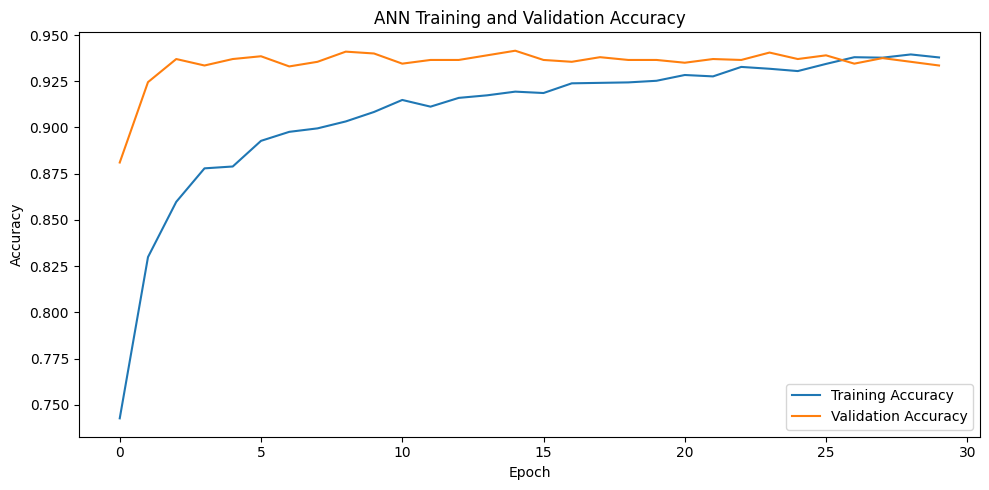

In [92]:
plt.figure(figsize=(10, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("ANN Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

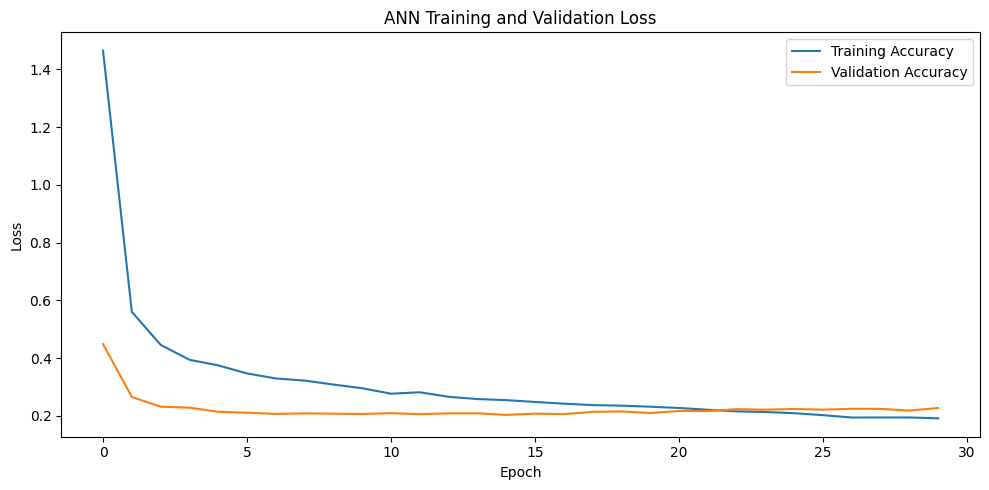

In [94]:
plt.figure(figsize=(10, 5))

plt.plot(
    history.history["loss"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Accuracy"
)

plt.title("ANN Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

In [95]:
# Predictions
ann_probabilities = ann_model.predict(
    X_test_ann,
    verbose=0
)

y_pred_ann = np.argmax(
    ann_probabilities,
    axis=1
)


In [96]:
ann_accuracy = accuracy_score(y_test_encoded, y_pred_ann)

ann_precision = precision_score(
    y_test_encoded,
    y_pred_ann,
    average="weighted"
)

ann_recall = recall_score(
    y_test_encoded,
    y_pred_ann,
    average="weighted"
)

ann_f1 = f1_score(
    y_test_encoded,
    y_pred_ann,
    average="weighted"
)

print("ANN Results")
print("-----------")
print("Accuracy :", round(ann_accuracy, 4))
print("Precision:", round(ann_precision, 4))
print("Recall   :", round(ann_recall, 4))
print("F1-Score :", round(ann_f1, 4))

ANN Results
-----------
Accuracy : 0.9211
Precision: 0.9233
Recall   : 0.9211
F1-Score : 0.9208


In [98]:
ann_results = {
    "Model": "ANN",
    "Accuracy": ann_accuracy,
    "Precision": ann_precision,
    "Recall": ann_recall,
    "F1-Score": ann_f1
}

ann_results

{'Model': 'ANN',
 'Accuracy': 0.9211038961038961,
 'Precision': 0.9232607514469513,
 'Recall': 0.9211038961038961,
 'F1-Score': 0.9207936573316474}

#### Baseline models Comparison

In [99]:
baseline_results = pd.DataFrame([
    logistic_results,
    svc_results,
    rf_results,
    ann_results
])

baseline_results

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.907792,0.912043,0.907792,0.907602
1,SVC,0.927597,0.930765,0.927597,0.927305
2,Random Forest,0.901948,0.907081,0.901948,0.901425
3,ANN,0.921104,0.923261,0.921104,0.920794


### Baseline Model Comparison

The four baseline machine learning models were compared using accuracy,
weighted precision, weighted recall and weighted F1-score.

SVC, Logistic Regression, Random Forest and ANN were trained using the same
sentence embeddings and evaluated on the same unseen testing dataset.
This provides a fair comparison of their baseline performance.

Based on these baseline results Hyperparameter Tuning will be done.

## Hyperparameter Tuning

### Logistic Regression Hyperparameter Tuning

RandomizedSearchCV is used to search for suitable hyperparameters for
the Logistic Regression model.

The main parameters considered are regularization strength, solver and
maximum number of iterations.

In [101]:
logistic_param_dist = {
    "C": [0.01, 0.1, 0.5, 1, 2, 5, 10],
    "solver": ["lbfgs", "newton-cg"],
    "max_iter": [500, 1000, 1500, 2000]
}

In [102]:
logistic_random = RandomizedSearchCV(
    estimator=LogisticRegression(),
    param_distributions=logistic_param_dist,
    n_iter=10,
    cv=5,
    scoring="f1_weighted",
    random_state=42,
    n_jobs=-1,
    verbose=1
)

In [103]:
logistic_random.fit(
    X_train_embeddings,
    y_train_encoded
)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegression()
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'C': [0.01, 0.1, ...], 'max_iter': [500, 1000, ...], 'solver': ['lbfgs', 'newton-cg']}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1_weighted'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if N

In [104]:
print("Best Logistic Regression Parameters:")
print(logistic_random.best_params_)

Best Logistic Regression Parameters:
{'solver': 'lbfgs', 'max_iter': 1000, 'C': 10}


In [105]:
print(
    "Best Logistic Regression CV F1:",
    logistic_random.best_score_
)

Best Logistic Regression CV F1: 0.9201097791760595


In [107]:
best_logistic_model = logistic_random.best_estimator_

In [108]:
y_pred_logistic_tuned = best_logistic_model.predict(
    X_test_embeddings
)

In [109]:
logistic_tuned_accuracy = accuracy_score(
    y_test_encoded,
    y_pred_logistic_tuned
)

logistic_tuned_precision = precision_score(
    y_test_encoded,
    y_pred_logistic_tuned,
    average="weighted"
)

logistic_tuned_recall = recall_score(
    y_test_encoded,
    y_pred_logistic_tuned,
    average="weighted"
)

logistic_tuned_f1 = f1_score(
    y_test_encoded,
    y_pred_logistic_tuned,
    average="weighted"
)

print("Tuned Logistic Regression Results")
print("---------------------------------")
print("Accuracy :", round(logistic_tuned_accuracy, 4))
print("Precision:", round(logistic_tuned_precision, 4))
print("Recall   :", round(logistic_tuned_recall, 4))
print("F1-Score :", round(logistic_tuned_f1, 4))

Tuned Logistic Regression Results
---------------------------------
Accuracy : 0.9279
Precision: 0.9309
Recall   : 0.9279
F1-Score : 0.9277


In [110]:
logistic_tuned_results = {
    "Model": "Logistic Regression (Tuned)",
    "Accuracy": logistic_tuned_accuracy,
    "Precision": logistic_tuned_precision,
    "Recall": logistic_tuned_recall,
    "F1-Score": logistic_tuned_f1
}

### Tuned Logistic Regression Results

RandomizedSearchCV was used to find a suitable combination of
hyperparameters for the Logistic Regression model.

The best parameters were:

- C = 10
- Solver = lbfgs
- Maximum iterations = 1000

Using these parameters, the tuned Logistic Regression model achieved
92.79% accuracy, 93.09% precision, 92.79% recall and 92.77% weighted
F1-score on the test dataset.

The tuned model will be compared with the other tuned models to select
the final model.

#### SVC Hyperparameter tuning

In [111]:
svc_param_dist = {
    "C": [0.1, 0.5, 1, 2, 5, 10, 20],
    "kernel": ["linear", "rbf"],
    "gamma": ["scale", "auto", 0.001, 0.01, 0.1]
}

### SVC Hyperparameter Tuning

RandomizedSearchCV is used to search for suitable hyperparameters for
the Support Vector Classifier (SVC).

The regularization parameter C, kernel type and gamma are varied to
identify a combination that provides better classification performance.

Weighted F1-score is used as the scoring metric because the dataset
contains 77 banking issue categories with some variation in class size.

In [112]:
svc_random = RandomizedSearchCV(
    estimator=SVC(probability=True),
    param_distributions=svc_param_dist,
    n_iter=10,
    cv=5,
    scoring="f1_weighted",
    random_state=42,
    n_jobs=-1,
    verbose=1
)

In [113]:
svc_random.fit(
    X_train_embeddings,
    y_train_encoded
)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVC(probability=True)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'C': [0.1, 0.5, ...], 'gamma': ['scale', 'auto', ...], 'kernel': ['linear', 'rbf']}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1_weighted'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if Non

In [114]:
print("Best SVC Parameters:")
print(svc_random.best_params_)

print("\nBest SVC CV F1 Score:")
print(svc_random.best_score_)

Best SVC Parameters:
{'kernel': 'linear', 'gamma': 0.001, 'C': 10}

Best SVC CV F1 Score:
0.9215244791041546


### Tuned SVC Results

RandomizedSearchCV was used to tune the Support Vector Classifier by
testing different values of C, kernel and gamma.

The best hyperparameter combination was:

- C = 10
- Kernel = linear
- Gamma = 0.001

The best cross-validation weighted F1-score obtained during tuning was
0.9215.

The tuned SVC model will now be evaluated on the unseen test dataset
and compared with the other models.

In [115]:
best_svc_model = svc_random.best_estimator_

In [116]:
y_pred_svc_tuned = best_svc_model.predict(
    X_test_embeddings
)

In [117]:
svc_tuned_accuracy = accuracy_score(
    y_test_encoded,
    y_pred_svc_tuned
)

svc_tuned_precision = precision_score(
    y_test_encoded,
    y_pred_svc_tuned,
    average="weighted"
)

svc_tuned_recall = recall_score(
    y_test_encoded,
    y_pred_svc_tuned,
    average="weighted"
)

svc_tuned_f1 = f1_score(
    y_test_encoded,
    y_pred_svc_tuned,
    average="weighted"
)

print("Tuned SVC Results")
print("-----------------")
print("Accuracy :", round(svc_tuned_accuracy, 4))
print("Precision:", round(svc_tuned_precision, 4))
print("Recall   :", round(svc_tuned_recall, 4))
print("F1-Score :", round(svc_tuned_f1, 4))

Tuned SVC Results
-----------------
Accuracy : 0.9273
Precision: 0.9288
Recall   : 0.9273
F1-Score : 0.927


In [118]:
svc_tuned_results = {
    "Model": "SVC (Tuned)",
    "Accuracy": svc_tuned_accuracy,
    "Precision": svc_tuned_precision,
    "Recall": svc_tuned_recall,
    "F1-Score": svc_tuned_f1
}

### Random Forest Hyperparameter Tuning

RandomizedSearchCV is used to tune the Random Forest classifier by
testing different combinations of the number of trees, tree depth,
minimum samples required for splitting and minimum samples required at
a leaf.

The weighted F1-score is used as the scoring metric to account for the
different class sizes in the BANKING77 dataset.

In [119]:
rf_param_dist = {
    "n_estimators": [100, 200, 300, 400],
    "max_depth": [None, 10, 20, 30, 40],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

In [120]:
rf_random = RandomizedSearchCV(
    estimator=RandomForestClassifier(
        random_state=42
    ),
    param_distributions=rf_param_dist,
    n_iter=10,
    cv=5,
    scoring="f1_weighted",
    random_state=42,
    n_jobs=-1,
    verbose=1
)

In [121]:
rf_random.fit(
    X_train_embeddings,
    y_train_encoded
)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [None, 10, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1_weighted'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be u

In [122]:
print("Best Random Forest Parameters:")
print(rf_random.best_params_)

print("\nBest Random Forest CV F1 Score:")
print(rf_random.best_score_)

Best Random Forest Parameters:
{'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None}

Best Random Forest CV F1 Score:
0.9075978717647224


In [123]:
best_rf_model = rf_random.best_estimator_

### Tuned Random Forest Results

RandomizedSearchCV was used to tune the Random Forest classifier using
different combinations of tree and splitting parameters.

The best hyperparameter combination was:

- Number of estimators = 300
- Minimum samples for split = 5
- Minimum samples at leaf = 1
- Maximum features = log2
- Maximum depth = None

The best cross-validation weighted F1-score obtained during tuning was
0.9076.

The tuned Random Forest model will now be evaluated on the unseen test
dataset and compared with the other tuned models.

In [124]:
y_pred_rf_tuned = best_rf_model.predict(
    X_test_embeddings
)

In [125]:
rf_tuned_accuracy = accuracy_score(
    y_test_encoded,
    y_pred_rf_tuned
)

rf_tuned_precision = precision_score(
    y_test_encoded,
    y_pred_rf_tuned,
    average="weighted"
)

rf_tuned_recall = recall_score(
    y_test_encoded,
    y_pred_rf_tuned,
    average="weighted"
)

rf_tuned_f1 = f1_score(
    y_test_encoded,
    y_pred_rf_tuned,
    average="weighted"
)

print("Tuned Random Forest Results")
print("---------------------------")
print("Accuracy :", round(rf_tuned_accuracy, 4))
print("Precision:", round(rf_tuned_precision, 4))
print("Recall   :", round(rf_tuned_recall, 4))
print("F1-Score :", round(rf_tuned_f1, 4))

Tuned Random Forest Results
---------------------------
Accuracy : 0.9117
Precision: 0.9164
Recall   : 0.9117
F1-Score : 0.9112


In [126]:
rf_tuned_results = {
    "Model": "Random Forest (Tuned)",
    "Accuracy": rf_tuned_accuracy,
    "Precision": rf_tuned_precision,
    "Recall": rf_tuned_recall,
    "F1-Score": rf_tuned_f1
}

## ANN Hyperparameter Tuning Using Optuna

Optuna is used to tune the hyperparameters of the Artificial Neural
Network. It performs an efficient search over different combinations of
hyperparameters instead of testing every possible combination.

The validation dataset is used to evaluate each trial, while the original
test dataset is kept separate for the final evaluation.

In [137]:
def objective(trial):

    units_1 = trial.suggest_int(
        "units_1",
        64,
        256
    )

    units_2 = trial.suggest_int(
        "units_2",
        32,
        128
    )

    dropout_1 = trial.suggest_float(
        "dropout_1",
        0.1,
        0.5,
        step = 0.1
    )

    dropout_2 = trial.suggest_float(
        "dropout_2",
        0.1,
        0.5,
        step = 0.1
    )

    learning_rate = trial.suggest_float(
        "learning_rate",
        1e-4,
        1e-2,
        log = True
    )

    batch_size = trial.suggest_categorical(
        "batch_size",
        [16,32,64]
    )


    model = Sequential([
        Dense(
            units_1,
            activation = "relu",
            input_shape = (X_ann_train.shape[1],)
        ),

        Dropout(dropout_1),

        Dense(
            units_2,
            activation = "relu"
        ),

        Dropout(dropout_2),

        Dense(
            77,
            activation = "softmax"
        )
    ])


    model.compile(
        optimizer = tf.keras.optimizers.Adam(learning_rate = learning_rate),
        loss = "sparse_categorical_crossentropy",
        metrics = ["accuracy"]
    )

    model.fit(
        X_ann_train,
        y_ann_train,
        validation_data = (X_ann_val, y_ann_val),
        epochs = 20,
        batch_size = batch_size,
        verbose = 0
    )


    val_probabilities = model.predict(
        X_ann_val,
        verbose = 0
    )

    y_val_pred = np.argmax(
        val_probabilities,
        axis = 1
    )

    val_f1 = f1_score(
        y_ann_val,
        y_val_pred,
        average = "weighted"
    )

    return val_f1

In [138]:
study = optuna.create_study(
    direction="maximize",
    study_name="BANKING77_ANN_Tuning"
)

[I 2026-09-01 22:14:03,371] A new study created in memory with name: BANKING77_ANN_Tuning


In [139]:
study.optimize(
    objective,
    n_trials=15
)

C:\Users\prema\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
[I 2026-09-01 22:14:20,491] Trial 0 finished with value: 0.904506641020991 and parameters: {'units_1': 85, 'units_2': 110, 'dropout_1': 0.30000000000000004, 'dropout_2': 0.2, 'learning_rate': 0.0008681757910066656, 'batch_size': 32}. Best is trial 0 with value: 0.904506641020991.
C:\Users\prema\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
[I 2026-09-

In [140]:
best_ann_params = study.best_params

print("Best ANN Parameters:")
print(best_ann_params)

Best ANN Parameters:
{'units_1': 133, 'units_2': 98, 'dropout_1': 0.4, 'dropout_2': 0.30000000000000004, 'learning_rate': 0.0008993802103530041, 'batch_size': 16}


In [141]:
from tensorflow.keras import Input

best_ann_model = Sequential([
    Input(shape=(X_ann_train.shape[1],)),

    Dense(
        best_ann_params["units_1"],
        activation="relu"
    ),

    Dropout(
        best_ann_params["dropout_1"]
    ),

    Dense(
        best_ann_params["units_2"],
        activation="relu"
    ),

    Dropout(
        best_ann_params["dropout_2"]
    ),

    Dense(
        77,
        activation="softmax"
    )
])

In [143]:
best_ann_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=best_ann_params["learning_rate"]
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [144]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [145]:
history_tuned_ann = best_ann_model.fit(
    X_ann_train,
    y_ann_train,
    validation_data=(X_ann_val, y_ann_val),
    epochs=30,
    batch_size=best_ann_params["batch_size"],
    callbacks=[early_stopping],
    shuffle=True,
    verbose=1
)

Epoch 1/30
501/501 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.2792 - loss: 2.9336 - val_accuracy: 0.7091 - val_loss: 1.3269
Epoch 2/30
501/501 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5871 - loss: 1.3825 - val_accuracy: 0.8201 - val_loss: 0.7737
Epoch 3/30
501/501 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6910 - loss: 1.0329 - val_accuracy: 0.8451 - val_loss: 0.6021
Epoch 4/30
501/501 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7422 - loss: 0.8421 - val_accuracy: 0.8646 - val_loss: 0.5105
Epoch 5/30
501/501 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7756 - loss: 0.7383 - val_accuracy: 0.8701 - val_loss: 0.4661
Epoch 6/30
501/501 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7933 - loss: 0.6770 - val_accuracy: 0.8821 - val_loss: 0.4239
Epoch 7/30
501/501 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8207 - loss: 0.6008 - val_accuracy: 0.8926 - val_loss: 0.3988
Epoch 8/30
501/501 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8269 - loss: 0.5639 - val_accuracy: 0.

In [146]:
tuned_ann_test_loss, tuned_ann_test_accuracy = best_ann_model.evaluate(
    X_test_ann,
    y_test_encoded,
    verbose=0
)

print("Tuned ANN Test Loss:", tuned_ann_test_loss)
print("Tuned ANN Test Accuracy:", tuned_ann_test_accuracy)

Tuned ANN Test Loss: 0.2997625172138214
Tuned ANN Test Accuracy: 0.9142857193946838


In [147]:
tuned_ann_probabilities = best_ann_model.predict(
    X_test_ann,
    verbose=0
)

y_pred_tuned_ann = np.argmax(
    tuned_ann_probabilities,
    axis=1
)

In [148]:
tuned_ann_accuracy = accuracy_score(
    y_test_encoded,
    y_pred_tuned_ann
)

tuned_ann_precision = precision_score(
    y_test_encoded,
    y_pred_tuned_ann,
    average="weighted"
)

tuned_ann_recall = recall_score(
    y_test_encoded,
    y_pred_tuned_ann,
    average="weighted"
)

tuned_ann_f1 = f1_score(
    y_test_encoded,
    y_pred_tuned_ann,
    average="weighted"
)

print("Tuned ANN Results")
print("-----------------")
print("Accuracy :", round(tuned_ann_accuracy, 4))
print("Precision:", round(tuned_ann_precision, 4))
print("Recall   :", round(tuned_ann_recall, 4))
print("F1-Score :", round(tuned_ann_f1, 4))

Tuned ANN Results
-----------------
Accuracy : 0.9143
Precision: 0.9181
Recall   : 0.9143
F1-Score : 0.9142


In [149]:
final_comparison = pd.DataFrame([
    {
        "Model": "Logistic Regression (Tuned)",
        "Accuracy": logistic_tuned_accuracy,
        "Precision": logistic_tuned_precision,
        "Recall": logistic_tuned_recall,
        "F1-Score": logistic_tuned_f1
    },
    {
        "Model": "SVC (Tuned)",
        "Accuracy": svc_tuned_accuracy,
        "Precision": svc_tuned_precision,
        "Recall": svc_tuned_recall,
        "F1-Score": svc_tuned_f1
    },
    {
        "Model": "ANN (Baseline)",
        "Accuracy": ann_accuracy,
        "Precision": ann_precision,
        "Recall": ann_recall,
        "F1-Score": ann_f1
    },
    {
        "Model": "ANN (Optuna Tuned)",
        "Accuracy": tuned_ann_accuracy,
        "Precision": tuned_ann_precision,
        "Recall": tuned_ann_recall,
        "F1-Score": tuned_ann_f1
    },
    {
        "Model": "Random Forest (Tuned)",
        "Accuracy": rf_tuned_accuracy,
        "Precision": rf_tuned_precision,
        "Recall": rf_tuned_recall,
        "F1-Score": rf_tuned_f1
    }
])

final_comparison

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression (Tuned),0.927922,0.930899,0.927922,0.927686
1,SVC (Tuned),0.927273,0.928834,0.927273,0.927027
2,ANN (Baseline),0.921104,0.923261,0.921104,0.920794
3,ANN (Optuna Tuned),0.914286,0.918127,0.914286,0.914231
4,Random Forest (Tuned),0.911688,0.916396,0.911688,0.911186


## Best Model Selection

The baseline and tuned models were compared using accuracy, precision,
recall and weighted F1-score on the unseen BANKING77 test dataset.

The tuned Logistic Regression model achieved the best overall
performance with an accuracy of 92.79% and a weighted F1-score of 92.77%.
The tuned SVC model performed very closely with an accuracy of 92.73%.

The baseline ANN achieved 92.11% accuracy, while the Optuna-tuned ANN
achieved 91.43%. Therefore, hyperparameter tuning did not improve the
ANN performance in this case.

Random Forest achieved 91.17% accuracy, which was lower than the other
models.

Based on the overall evaluation metrics, Logistic Regression was
selected as the final model for the application.

In [150]:
print(type(X_train_embeddings))
print(X_train_embeddings.shape)

<class 'numpy.ndarray'>
(10003, 384)


In [153]:
# Create folder for saved artifacts
os.makedirs("models", exist_ok=True)

# Save the final Logistic Regression model
joblib.dump(
    best_logistic_model,
    "models/best_model.pkl"
)

# Save the label encoder
joblib.dump(
    label_encoder,
    "models/label_encoder.pkl"
)

# Save the Sentence Transformer model
embedding_model.save(
    "models/embedding_model"
)

print("Model saved successfully.")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved successfully.


In [154]:
print(os.listdir("models"))

['best_model.pkl', 'embedding_model', 'label_encoder.pkl']


#### Testing the Saved Models

In [155]:
# Load model
loaded_model = joblib.load(
    "models/best_model.pkl"
)

# Load label encoder
loaded_label_encoder = joblib.load(
    "models/label_encoder.pkl"
)

# Load embedding model
loaded_embedding_model = SentenceTransformer(
    "models/embedding_model"
)

print("All artifacts loaded successfully.")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

All artifacts loaded successfully.


In [156]:
# Test prediction using the saved artifacts

sample_text = X_test.iloc[0]

# Convert text into embedding
sample_embedding = loaded_embedding_model.encode(
    [sample_text]
)

# Make prediction
predicted_encoded = loaded_model.predict(
    sample_embedding
)

# Convert encoded prediction back to original category
predicted_category = loaded_label_encoder.inverse_transform(
    predicted_encoded
)[0]

print("Input:", sample_text)
print("Predicted Issue:", predicted_category)

Input: how do i locate my card
Predicted Issue: lost_or_stolen_card


In [157]:
# Get prediction confidence

prediction_probabilities = loaded_model.predict_proba(
    sample_embedding
)

confidence = prediction_probabilities.max()

print("Confidence:", round(confidence * 100, 2), "%")

Confidence: 58.9 %
